In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
df = pd.read_csv(r"C:\Users\hp\Downloads\dirty_cafe_sales.csv")
df 

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [4]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [5]:
for col in df.columns:
    print(col, df[col].unique())

Transaction ID ['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']
Item ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
Quantity ['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]
Price Per Unit ['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']
Total Spent ['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN' '2.0' '1.0' '7.5' '4.5' '1.5']
Payment Method ['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]
Location ['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
Transaction Date ['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' 'ERROR' '2023-05-03' '2023-06-01' '2023-03-21' '2023-11-15'
 '2023-06-10' '2023-02-24' '2023-03-25' '2023-01-15' '2023-04-04'
 '2023-03-30' '2023-12-01' '2023-09-18' '2023-06-03' '2023-12-13'
 '2023-04-20' '2023-04-10' '2023-03

In [6]:
error_rows = df[
    df.apply(lambda row: row.astype(str).str.contains("ERROR").any(), axis=1)
]

print(error_rows)


     Transaction ID      Item Quantity Price Per Unit Total Spent  \
2       TXN_4271903    Cookie        4            1.0       ERROR   
6       TXN_4433211   UNKNOWN        3            3.0         9.0   
11      TXN_3051279  Sandwich        2            4.0         8.0   
14      TXN_8915701     ERROR        2            1.5         3.0   
18      TXN_8876618      Cake        5            3.0        15.0   
...             ...       ...      ...            ...         ...   
9957    TXN_6487003    Coffee    ERROR            2.0         8.0   
9958    TXN_4125474     ERROR        2            5.0        10.0   
9977    TXN_5548914     Juice        2            3.0       ERROR   
9981    TXN_4583012     ERROR        5            4.0        20.0   
9988    TXN_9594133      Cake        5            3.0         NaN   

      Payment Method  Location Transaction Date  
2        Credit Card  In-store       2023-07-19  
6              ERROR  Takeaway       2023-10-06  
11       Credit Card 

In [7]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['Transaction Date'] = df['Transaction Date'].ffill()
df['Transaction Date'] = df['Transaction Date'].dt.date

In [8]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [9]:
df.loc[df['Total Spent'].isna(), 'Total Spent'] = (
    df['Quantity'] * df['Price Per Unit']
)

In [10]:
df.loc[df['Quantity'].isna(), 'Quantity'] = (
    df['Total Spent'] / df['Price Per Unit']
)

In [11]:
df.loc[df['Price Per Unit'].isna(), 'Price Per Unit'] = (
    df['Total Spent'] / df['Quantity']
)

In [12]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity              38
Price Per Unit        38
Total Spent           40
Payment Method      2579
Location            3265
Transaction Date       0
dtype: int64

In [13]:
problem_rows = df[
    df[['Quantity', 'Price Per Unit', 'Total Spent']].isna().any(axis=1)
]
print(problem_rows)

     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
65      TXN_4987129  Sandwich       3.0             NaN          NaN   
236     TXN_8562645     Salad       NaN             5.0          NaN   
278     TXN_3229409     Juice       NaN             3.0          NaN   
629     TXN_9289174      Cake       NaN             NaN         12.0   
641     TXN_2962976     Juice       NaN             3.0          NaN   
738     TXN_8696094  Sandwich       NaN             4.0          NaN   
912     TXN_1575608  Sandwich       NaN             NaN         20.0   
1008    TXN_7225428       Tea       NaN             NaN          3.0   
1436    TXN_7590801       Tea       NaN             NaN          6.0   
1482    TXN_3593060  Smoothie       NaN             NaN         16.0   
1674    TXN_9367492       Tea       2.0             NaN          NaN   
1761    TXN_3611851       NaN       4.0             NaN          NaN   
2229    TXN_8498613  Sandwich       2.0             NaN         

In [14]:
item_prices = df.dropna(subset=['Price Per Unit']).groupby('Item')['Price Per Unit'].unique()
for item, prices in item_prices.items():
    print(f"{item}: Price Per Unit = {list(prices)}")


Cake: Price Per Unit = [np.float64(3.0)]
Coffee: Price Per Unit = [np.float64(2.0)]
Cookie: Price Per Unit = [np.float64(1.0)]
ERROR: Price Per Unit = [np.float64(1.5), np.float64(3.0), np.float64(5.0), np.float64(4.0), np.float64(2.0), np.float64(1.0)]
Juice: Price Per Unit = [np.float64(3.0)]
Salad: Price Per Unit = [np.float64(5.0)]
Sandwich: Price Per Unit = [np.float64(4.0)]
Smoothie: Price Per Unit = [np.float64(4.0)]
Tea: Price Per Unit = [np.float64(1.5)]
UNKNOWN: Price Per Unit = [np.float64(3.0), np.float64(1.0), np.float64(5.0), np.float64(4.0), np.float64(1.5), np.float64(2.0)]


In [15]:
item_prices = df.dropna(subset=['Price Per Unit']).groupby('Item')['Price Per Unit'].unique()
fixed_prices = {item: prices[0] for item, prices in item_prices.items() if len(prices) == 1}
df.loc[df['Price Per Unit'].isna(), 'Price Per Unit'] = df['Item'].map(fixed_prices)
df.loc[df['Total Spent'].isna(), 'Total Spent'] = df['Quantity'] * df['Price Per Unit']
df.loc[df['Quantity'].isna(), 'Quantity'] = df['Total Spent'] / df['Price Per Unit']

In [16]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      2579
Location            3265
Transaction Date       0
dtype: int64

In [17]:
problem_rows = df[
    df[['Quantity', 'Price Per Unit', 'Total Spent']].isna().any(axis=1)
]
print(problem_rows)


     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
236     TXN_8562645     Salad       NaN             5.0          NaN   
278     TXN_3229409     Juice       NaN             3.0          NaN   
641     TXN_2962976     Juice       NaN             3.0          NaN   
738     TXN_8696094  Sandwich       NaN             4.0          NaN   
1761    TXN_3611851       NaN       4.0             NaN          NaN   
2289    TXN_7524977   UNKNOWN       4.0             NaN          NaN   
2796    TXN_9188692      Cake       NaN             3.0          NaN   
3203    TXN_4565754  Smoothie       NaN             4.0          NaN   
3224    TXN_6297232    Coffee       NaN             2.0          NaN   
3401    TXN_3251829       Tea       NaN             1.5          NaN   
3779    TXN_7376255   UNKNOWN       NaN             NaN         25.0   
4152    TXN_9646000     ERROR       2.0             NaN          NaN   
4257    TXN_6470865    Coffee       NaN             2.0         

In [18]:
df = df.drop(df[df['Price Per Unit'].isna()].index)

In [19]:
df.isnull().sum()

Transaction ID         0
Item                 331
Quantity              20
Price Per Unit         0
Total Spent           20
Payment Method      2577
Location            3262
Transaction Date       0
dtype: int64

In [20]:
problem_rows = df[
    df[['Quantity', 'Price Per Unit', 'Total Spent']].isna().any(axis=1)
]
print(problem_rows)

     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
236     TXN_8562645     Salad       NaN             5.0          NaN   
278     TXN_3229409     Juice       NaN             3.0          NaN   
641     TXN_2962976     Juice       NaN             3.0          NaN   
738     TXN_8696094  Sandwich       NaN             4.0          NaN   
2796    TXN_9188692      Cake       NaN             3.0          NaN   
3203    TXN_4565754  Smoothie       NaN             4.0          NaN   
3224    TXN_6297232    Coffee       NaN             2.0          NaN   
3401    TXN_3251829       Tea       NaN             1.5          NaN   
4257    TXN_6470865    Coffee       NaN             2.0          NaN   
5841    TXN_5884081    Cookie       NaN             1.0          NaN   
7029    TXN_4628338    Coffee       NaN             2.0          NaN   
7297    TXN_9944500  Smoothie       NaN             4.0          NaN   
8021    TXN_2428781     Salad       NaN             5.0         

In [21]:
df = df.drop(df[(df['Price Per Unit'].notna()) & 
                df['Quantity'].isna() & 
                df['Total Spent'].isna()].index)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9974 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9974 non-null   object 
 1   Item              9643 non-null   object 
 2   Quantity          9974 non-null   float64
 3   Price Per Unit    9974 non-null   float64
 4   Total Spent       9974 non-null   float64
 5   Payment Method    7404 non-null   object 
 6   Location          6717 non-null   object 
 7   Transaction Date  9974 non-null   object 
dtypes: float64(3), object(5)
memory usage: 701.3+ KB


In [23]:
df.isnull().sum()

Transaction ID         0
Item                 331
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2570
Location            3257
Transaction Date       0
dtype: int64

In [24]:
df['Item'] = df['Item'].replace(['ERROR', 'UNKNOWN'], pd.NA)

In [25]:
# Coffee
df.loc[(df['Item'].isna()) & (df['Price Per Unit'] == 2.0), 'Item'] = 'Coffee'

# Cookie
df.loc[(df['Item'].isna()) & (df['Price Per Unit'] == 1.0), 'Item'] = 'Cookie'

# Salad
df.loc[(df['Item'].isna()) & (df['Price Per Unit'] == 5.0), 'Item'] = 'Salad'

# Tea
df.loc[(df['Item'].isna()) & (df['Price Per Unit'] == 1.5), 'Item'] = 'Tea'


In [26]:
df.isnull().sum()

Transaction ID         0
Item                 474
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2570
Location            3257
Transaction Date       0
dtype: int64

In [27]:
problem_rows = df[
    df[['Item']].isna().any(axis=1)
]
print(problem_rows)

     Transaction ID  Item  Quantity  Price Per Unit  Total Spent  \
6       TXN_4433211  <NA>       3.0             3.0          9.0   
8       TXN_4717867   NaN       5.0             3.0         15.0   
36      TXN_6855453  <NA>       4.0             3.0         12.0   
61      TXN_8051289   NaN       1.0             3.0          3.0   
69      TXN_8471743  <NA>       5.0             3.0         15.0   
...             ...   ...       ...             ...          ...   
9910    TXN_2338617  <NA>       2.0             3.0          6.0   
9918    TXN_2292088  <NA>       1.0             4.0          4.0   
9946    TXN_8807600  <NA>       1.0             4.0          4.0   
9981    TXN_4583012  <NA>       5.0             4.0         20.0   
9994    TXN_7851634  <NA>       4.0             4.0         16.0   

      Payment Method  Location Transaction Date  
6              ERROR  Takeaway       2023-10-06  
8                NaN  Takeaway       2023-07-28  
36               NaN  In-store   

In [28]:
df = df[~df['Item'].isin(['Unknown', 'ERROR'])]
df = df.dropna(subset=['Item'])

In [29]:
df['Location'] = df['Location'].replace(['ERROR', 'UNKNOWN'], 'Not Specified')
df['Location'] = df['Location'].fillna('Not Specified')
df['Payment Method'] = df['Payment Method'].replace(['ERROR', 'UNKNOWN'], 'Not Specified')
df['Payment Method'] = df['Payment Method'].fillna('Not Specified')

In [30]:
print(df.isnull().sum())

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [31]:
df.to_csv(r"C:\Users\hp\Downloads/cafe_sales_cleaned_data.csv", index=False)

In [32]:
df.to_excel(r"C:\Users\hp\Downloads/cafe_sales_cleaned_data1.xlsx", index=False)

## Total Units Sold by Item

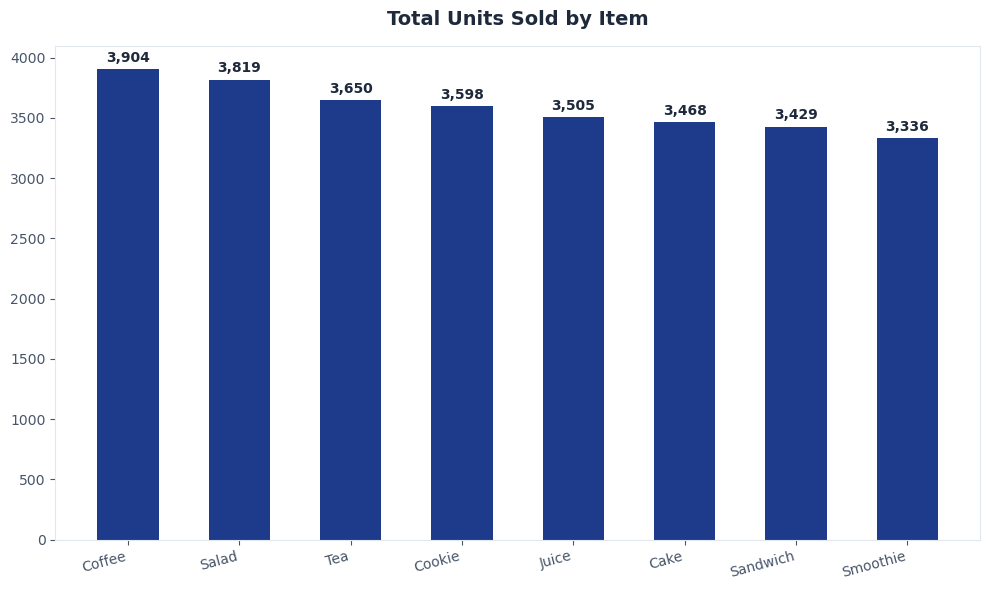

In [33]:
df_res = df.copy()
df_res['Item'] = df_res['Item'].replace('Unkown', 'Not Specified')
item_qty = df_res.groupby('Item')['Quantity'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')
BAR_COLOR = '#1E3A8A' 
bars = ax.bar(item_qty.index, item_qty.values, color=BAR_COLOR, width=0.55, edgecolor='none')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + (height*0.01), f'{int(height):,}', 
             va='bottom', ha='center', fontsize=10, fontweight='bold', color='#1E293B')
ax.set_title('Total Units Sold by Item', fontsize=14, fontweight='bold', color='#1E293B', pad=15)
ax.tick_params(colors='#475569', labelsize=10)
ax.set_xticks(range(len(item_qty)))
ax.set_xticklabels(item_qty.index, rotation=15, ha='right')
for spine in ax.spines.values(): spine.set_color('#E2E8F0')
ax.grid(False, axis='x')
plt.tight_layout()
plt.show()

## Product Sales Share Percentage

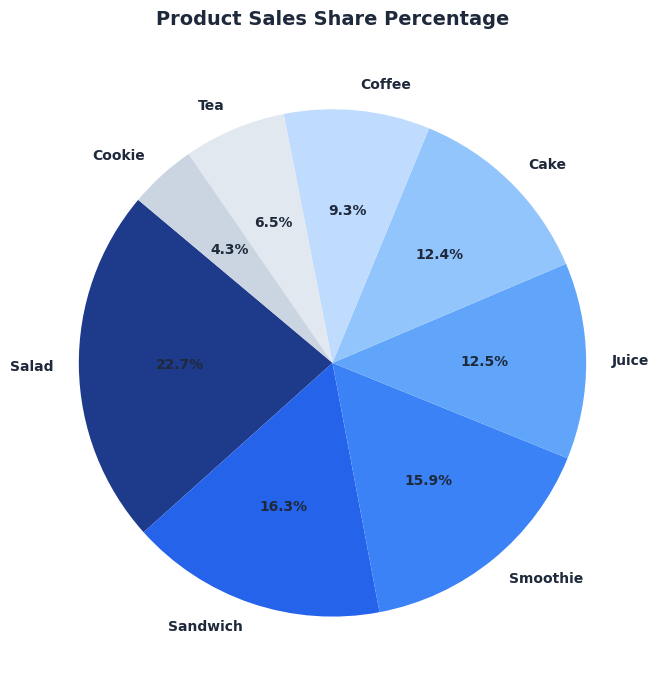

In [34]:
df_res = df.copy()
df_res['Item'] = df_res['Item'].replace('Unkown', 'Not Specified')
item_shares = df_res.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
CHART_COLORS = ['#1E3A8A', '#2563EB', '#3B82F6', '#60A5FA', '#93C5FD', '#BFDBFE', '#E2E8F0', '#CBD5E1', '#94A3B8']
ax.pie(item_shares, labels=item_shares.index, autopct='%1.1f%%', startangle=140, 
       colors=CHART_COLORS[:len(item_shares)], textprops={'fontsize': 10, 'weight': 'bold', 'color': '#1E293B'})
ax.set_title('Product Sales Share Percentage', fontsize=14, fontweight='bold', color='#1E293B', pad=15)
plt.tight_layout()
plt.show()

## Monthly Sales Trend Over Time

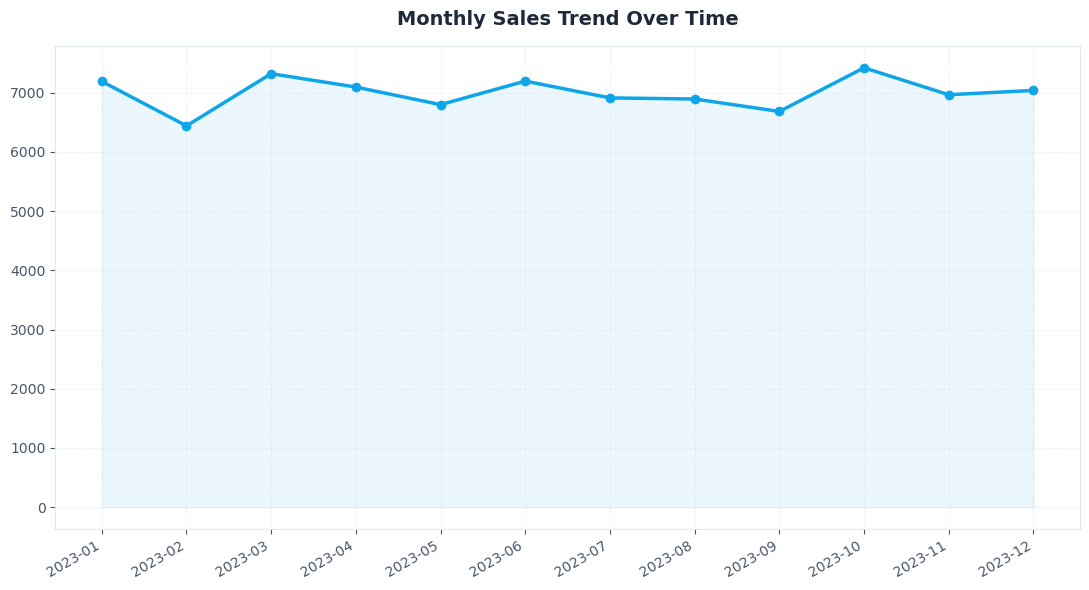

In [35]:
df_res = df.copy()
df_res['Transaction Date'] = pd.to_datetime(df_res['Transaction Date'], errors='coerce').ffill()
df_res['Year-Month'] = df_res['Transaction Date'].dt.to_period('M')
monthly_sales = df_res.groupby('Year-Month')['Total Spent'].sum()
monthly_x = monthly_sales.index.astype(str)
fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')
ax.set_facecolor('white')
LINE_COLOR = '#0EA5E9'
FILL_COLOR = '#0EA5E9'
ax.plot(monthly_x, monthly_sales.values, color=LINE_COLOR, linewidth=2.5, marker='o', markersize=6)
ax.fill_between(monthly_x, monthly_sales.values, color=FILL_COLOR, alpha=0.08)
ax.set_title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold', color='#1E293B', pad=15)
ax.tick_params(colors='#475569', labelsize=10)
ax.set_xticks(range(len(monthly_x)))
ax.set_xticklabels(monthly_x, rotation=30, ha='right')
for spine in ax.spines.values(): spine.set_color('#E2E8F0')
ax.grid(True, linestyle=':', alpha=0.5, color='#CBD5E1')
plt.tight_layout()
plt.show()

## Sales Breakdown by Payment Method per Item

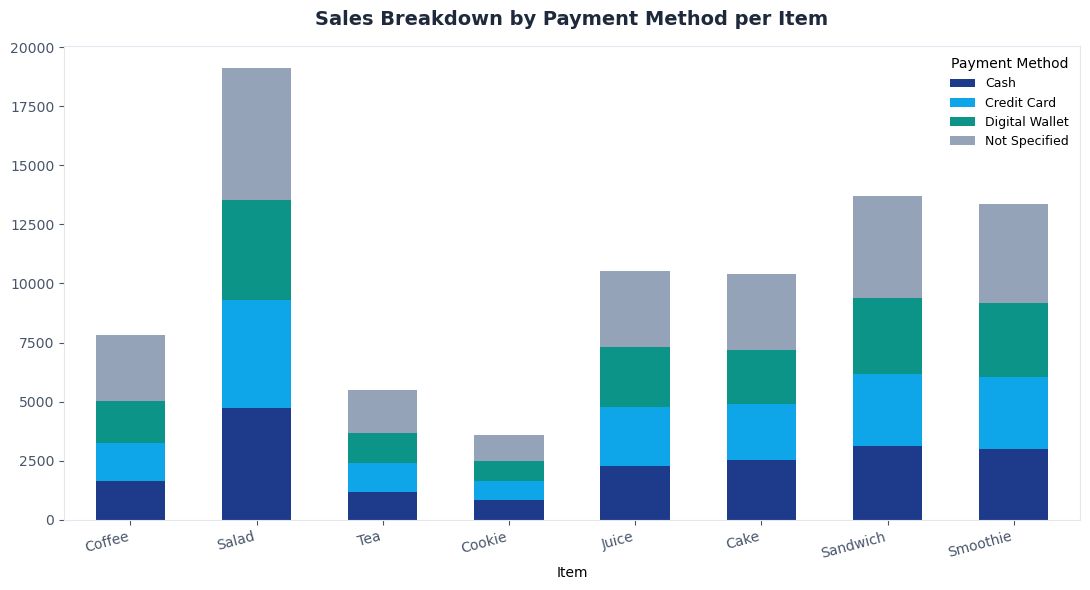

In [36]:
plt.clf()
plt.close('all')
df_res = df.copy()
df_res['Item'] = df_res['Item'].replace('Unkown', 'Not Specified')
df_res['Payment Method'] = df_res['Payment Method'].replace(['ERROR', 'UNKNOWN'], 'Not Specified').fillna('Not Specified')
item_order = df_res.groupby('Item')['Quantity'].sum().sort_values(ascending=False).index
payment_pivot = df_res.pivot_table(index='Item', columns='Payment Method', values='Total Spent', aggfunc='sum').fillna(0).loc[item_order]
fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')
ax.set_facecolor('white')
PAYMENT_COLORS = ['#1E3A8A', '#0EA5E9', '#0D9488', '#94A3B8']
payment_pivot.plot(kind='bar', stacked=True, ax=ax, color=PAYMENT_COLORS[:len(payment_pivot.columns)], width=0.55, edgecolor='none')
ax.set_title('Sales Breakdown by Payment Method per Item', fontsize=14, fontweight='bold', color='#1E293B', pad=15)
ax.tick_params(colors='#475569', labelsize=10)
ax.set_xticks(range(len(payment_pivot)))
ax.set_xticklabels(payment_pivot.index, rotation=15, ha='right')
ax.legend(title='Payment Method', frameon=False, fontsize=9)
for spine in ax.spines.values(): 
    spine.set_color('#E2E8F0')
ax.grid(False, axis='x')
plt.tight_layout()
plt.show()

## Sales Density Heatmap (Item vs Location)

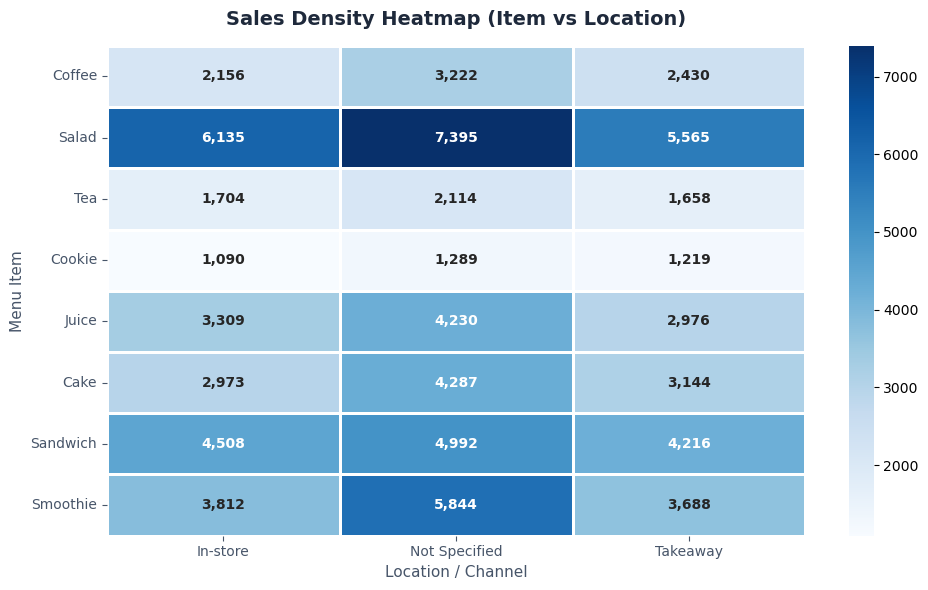

In [37]:
df_res = df.copy()
df_res['Item'] = df_res['Item'].replace('Unkown', 'Not Specified')
df_res['Location'] = df_res['Location'].replace(['ERROR', 'UNKNOWN'], 'Not Specified').fillna('Not Specified')
item_order = df_res.groupby('Item')['Quantity'].sum().sort_values(ascending=False).index
heatmap_data = df_res.pivot_table(index='Item', columns='Location', values='Total Spent', aggfunc='sum').fillna(0).loc[item_order]
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
HEATMAP_THEME = "Blues" 
sns.heatmap(heatmap_data, annot=True, fmt=",.0f", cmap=HEATMAP_THEME, cbar=True, 
            linewidths=1, linecolor='white', ax=ax, annot_kws={'weight': 'bold', 'size': 10})
ax.set_title('Sales Density Heatmap (Item vs Location)', fontsize=14, fontweight='bold', color='#1E293B', pad=15)
ax.set_xlabel('Location / Channel', fontsize=11, color='#475569')
ax.set_ylabel('Menu Item', fontsize=11, color='#475569')
ax.tick_params(colors='#475569', labelsize=10)
plt.tight_layout()
plt.show()

## Price Distribution Histogram

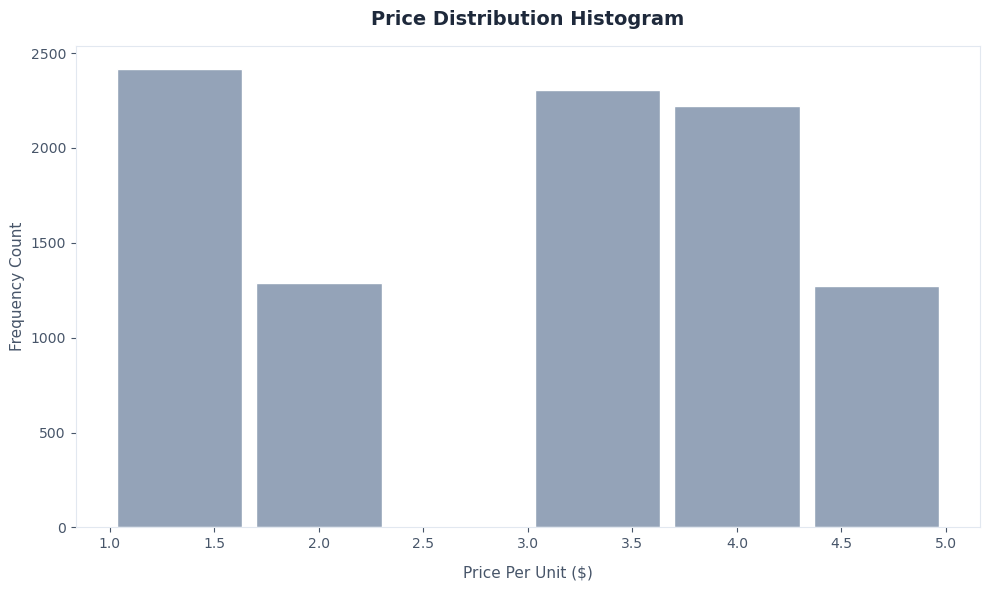

In [38]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')
HIST_COLOR = '#94A3B8'
ax.hist(df['Price Per Unit'], bins=6, color=HIST_COLOR, edgecolor='white', rwidth=0.9)
ax.set_title('Price Distribution Histogram', fontsize=14, fontweight='bold', color='#1E293B', pad=15)
ax.set_xlabel('Price Per Unit ($)', fontsize=11, color='#475569', labelpad=10)
ax.set_ylabel('Frequency Count', fontsize=11, color='#475569')
ax.tick_params(colors='#475569', labelsize=10)
for spine in ax.spines.values(): spine.set_color('#E2E8F0')
ax.grid(False, axis='x')
plt.tight_layout()
plt.show()

## Café Sales Dashboard

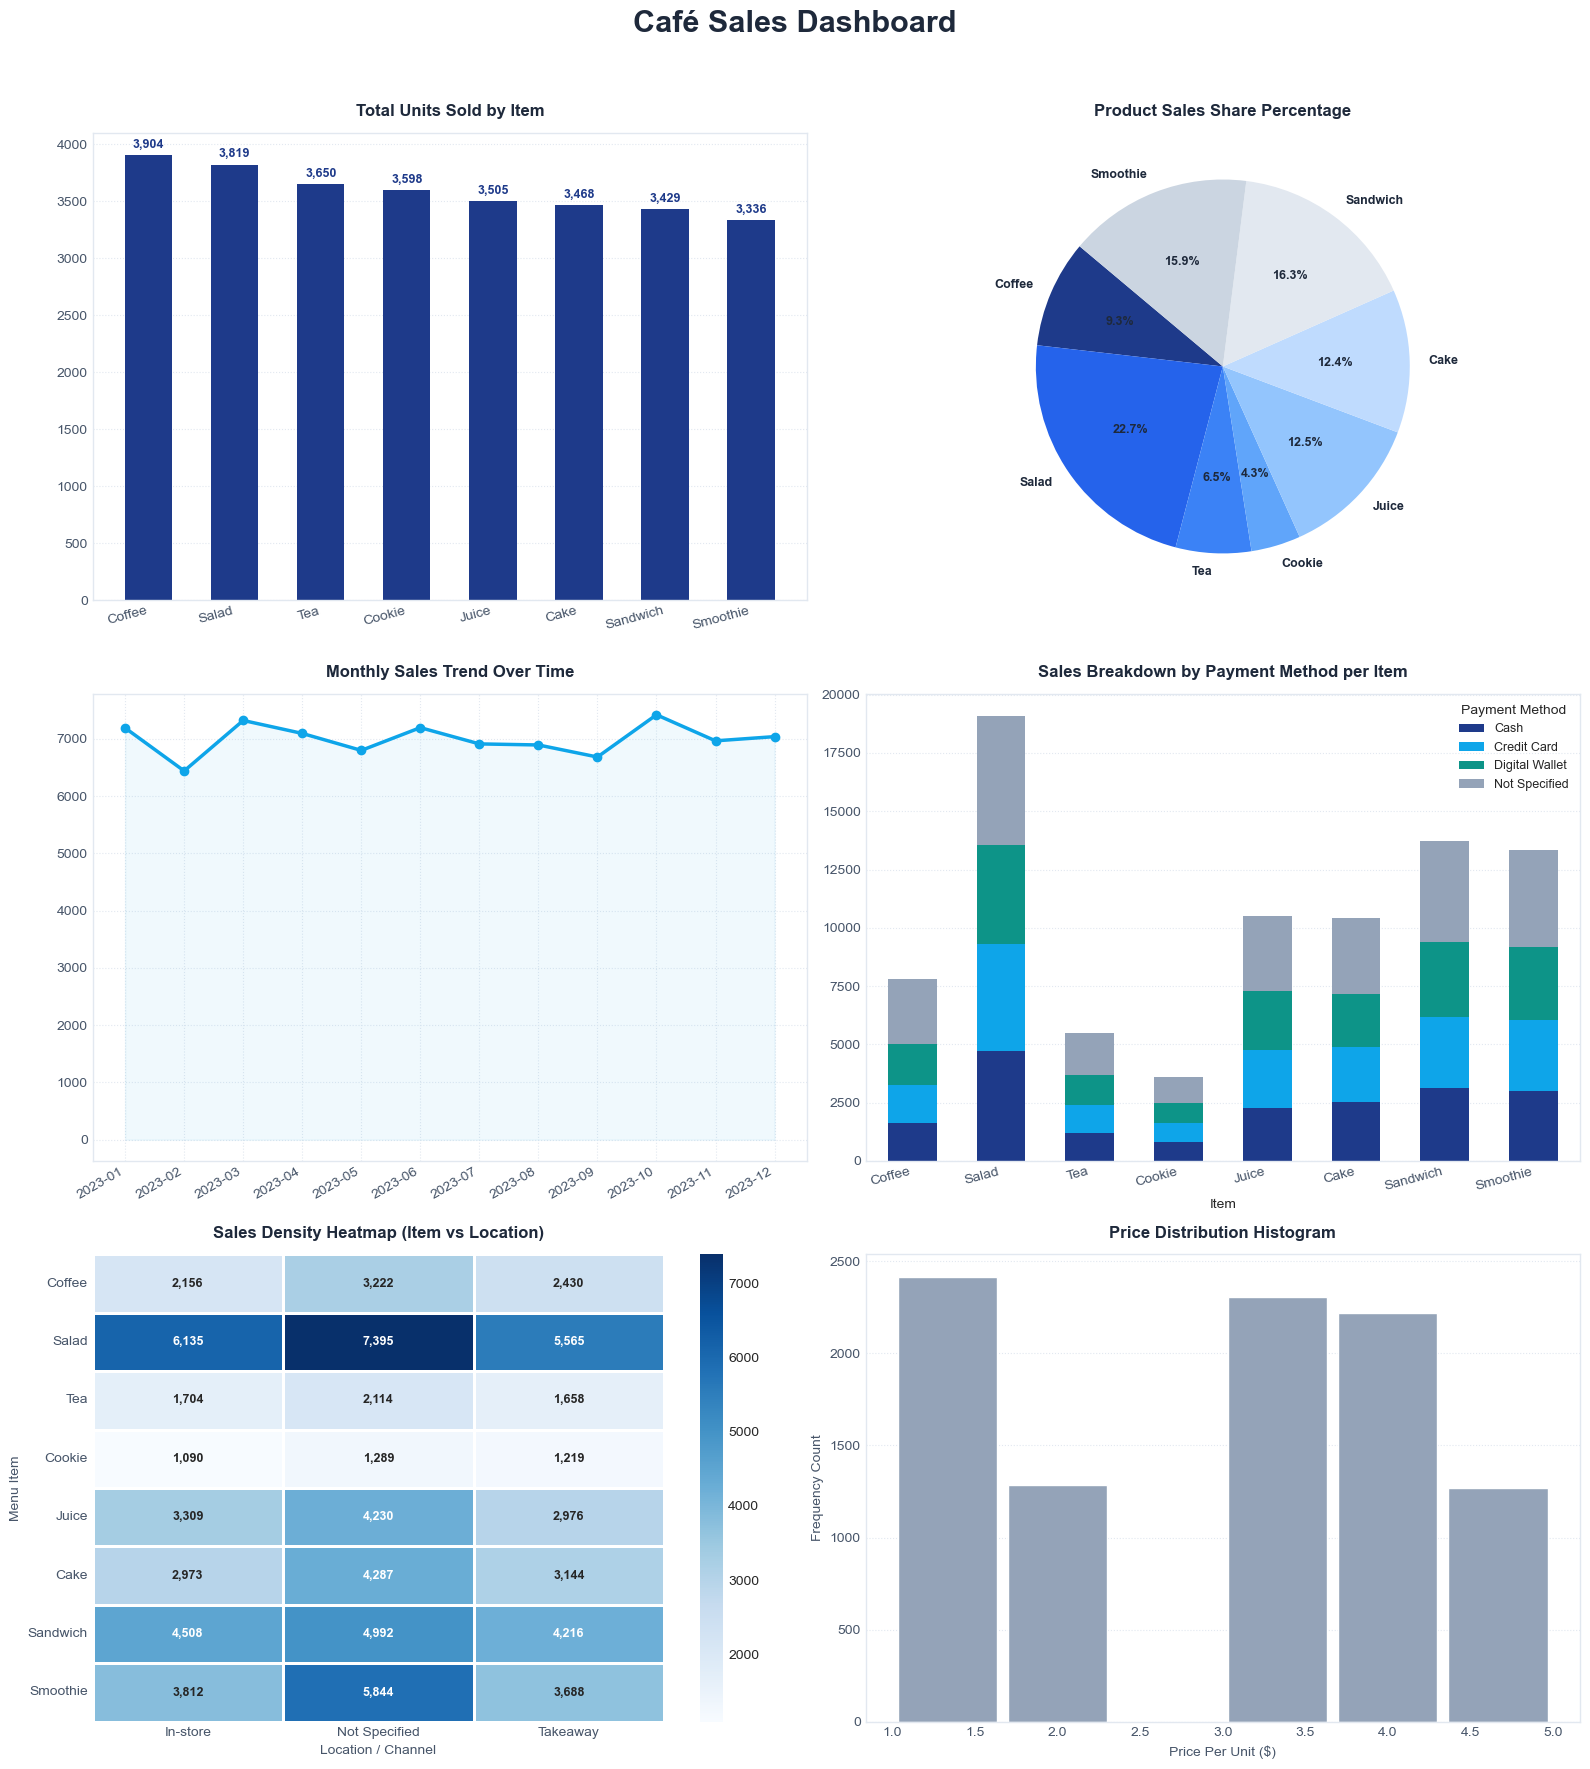

In [40]:
plt.clf()
plt.close('all')
df_dashboard = df.copy()
df_dashboard['Location'] = df_dashboard['Location'].replace(['ERROR', 'UNKNOWN'], 'Not Specified').fillna('Not Specified')
df_dashboard['Payment Method'] = df_dashboard['Payment Method'].replace(['ERROR', 'UNKNOWN'], 'Not Specified').fillna('Not Specified')
df_dashboard['Item'] = df_dashboard['Item'].replace('Unkown', 'Not Specified')
df_dashboard['Transaction Date'] = pd.to_datetime(df_dashboard['Transaction Date'], errors='coerce').ffill()
df_dashboard['Year-Month'] = df_dashboard['Transaction Date'].dt.to_period('M')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
mpl.rcParams['grid.color'] = '#E2E8F0'
mpl.rcParams['grid.linestyle'] = ':'
fig, axes = plt.subplots(3, 2, figsize=(16, 18), facecolor='white')
fig.suptitle('Café Sales Dashboard', fontsize=22, fontweight='bold', color='#1E293B', y=0.98)
COLOR_PRIMARY = '#1E3A8A'   
COLOR_SECONDARY = '#0EA5E9'
COLOR_ACCENT = '#0D9488'    
COLOR_MUTED = '#94A3B8'     
TEXT_COLOR = '#475569'      
# ----------------------------------------------------
ax1 = axes[0, 0]
ax1.set_facecolor('white')
item_qty = df_dashboard.groupby('Item')['Quantity'].sum().sort_values(ascending=False)
bars1 = ax1.bar(item_qty.index, item_qty.values, color=COLOR_PRIMARY, width=0.55, edgecolor='none')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (height*0.01), f'{int(height):,}', 
             va='bottom', ha='center', fontsize=9, fontweight='bold', color='#1E3A8A')
ax1.set_title('Total Units Sold by Item', fontsize=12, fontweight='bold', color='#1E293B', pad=12)
ax1.tick_params(colors=TEXT_COLOR, labelsize=10)
ax1.set_xticks(range(len(item_qty)))
ax1.set_xticklabels(item_qty.index, rotation=15, ha='right')
for spine in ax1.spines.values(): spine.set_color('#E2E8F0')
ax1.grid(False, axis='x')
# ----------------------------------------------------
ax2 = axes[0, 1]
item_shares = df_dashboard.groupby('Item')['Total Spent'].sum().loc[item_qty.index]
blue_shades = ['#1E3A8A', '#2563EB', '#3B82F6', '#60A5FA', '#93C5FD', '#BFDBFE', '#E2E8F0', '#CBD5E1', '#94A3B8']
ax2.pie(item_shares, labels=item_shares.index, autopct='%1.1f%%', startangle=140, 
       colors=blue_shades[:len(item_shares)], textprops={'fontsize': 9, 'weight': 'bold', 'color': '#1E293B'})
ax2.set_title('Product Sales Share Percentage', fontsize=12, fontweight='bold', color='#1E293B', pad=12)
# ----------------------------------------------------
ax3 = axes[1, 0]
ax3.set_facecolor('white')
monthly_sales = df_dashboard.groupby('Year-Month')['Total Spent'].sum()
monthly_x = monthly_sales.index.astype(str)
ax3.plot(monthly_x, monthly_sales.values, color=COLOR_SECONDARY, linewidth=2.5, marker='o', markersize=6)
ax3.fill_between(monthly_x, monthly_sales.values, color=COLOR_SECONDARY, alpha=0.06)
ax3.set_title('Monthly Sales Trend Over Time', fontsize=12, fontweight='bold', color='#1E293B', pad=12)
ax3.tick_params(colors=TEXT_COLOR, labelsize=10)
ax3.set_xticks(range(len(monthly_x)))
ax3.set_xticklabels(monthly_x, rotation=30, ha='right')
for spine in ax3.spines.values(): spine.set_color('#E2E8F0')
# ----------------------------------------------------
ax4 = axes[1, 1]
ax4.set_facecolor('white')
payment_pivot = df_dashboard.pivot_table(index='Item', columns='Payment Method', values='Total Spent', aggfunc='sum').fillna(0)
payment_pivot = payment_pivot.loc[item_qty.index]
payment_colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_MUTED]
payment_pivot.plot(kind='bar', stacked=True, ax=ax4, color=payment_colors[:len(payment_pivot.columns)], width=0.55, edgecolor='none')
ax4.set_title('Sales Breakdown by Payment Method per Item', fontsize=12, fontweight='bold', color='#1E293B', pad=12)
ax4.tick_params(colors=TEXT_COLOR, labelsize=10)
ax4.set_xticks(range(len(payment_pivot)))
ax4.set_xticklabels(payment_pivot.index, rotation=15, ha='right')
ax4.legend(title='Payment Method', frameon=False, fontsize=9)
for spine in ax4.spines.values(): spine.set_color('#E2E8F0')
ax4.grid(False, axis='x')
# ----------------------------------------------------
ax5 = axes[2, 0]
heatmap_data = df_dashboard.pivot_table(index='Item', columns='Location', values='Total Spent', aggfunc='sum').fillna(0)
heatmap_data = heatmap_data.loc[item_qty.index]
sns.heatmap(heatmap_data, annot=True, fmt=",.0f", cmap="Blues", cbar=True, linewidths=1, linecolor='white', ax=ax5, annot_kws={'weight': 'bold', 'size': 9})
ax5.set_title('Sales Density Heatmap (Item vs Location)', fontsize=12, fontweight='bold', color='#1E293B', pad=12)
ax5.set_xlabel('Location / Channel', fontsize=10, color=TEXT_COLOR)
ax5.set_ylabel('Menu Item', fontsize=10, color=TEXT_COLOR)
ax5.tick_params(colors=TEXT_COLOR, labelsize=10)
# ----------------------------------------------------
ax6 = axes[2, 1]
ax6.set_facecolor('white')
ax6.hist(df_dashboard['Price Per Unit'], bins=6, color=COLOR_MUTED, edgecolor='white', rwidth=0.9)
ax6.set_title('Price Distribution Histogram', fontsize=12, fontweight='bold', color='#1E293B', pad=12)
ax6.set_xlabel('Price Per Unit ($)', fontsize=10, color=TEXT_COLOR, labelpad=5)
ax6.set_ylabel('Frequency Count', fontsize=10, color=TEXT_COLOR)
ax6.tick_params(colors=TEXT_COLOR, labelsize=10)
for spine in ax6.spines.values(): spine.set_color('#E2E8F0')
ax6.grid(False, axis='x')
plt.savefig('Cafe_Sales_Executive_6_Chart_Dashboard.png', dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()